# Moank Flex Plus vs AMF Räntefond Kort on Avanza over 3 years

Compare a one-time lump sum held for three years in (1) Moank Flex Plus, whose current rate is variable, (2) AMF Räntefond Kort in an ordinary fund account, and (3) the same fund in an Avanza ISK. The notebook compares a three-year Moank illustration at today's rate with historical rolling three-year outcomes for the fund. Fund outcomes are historical illustrations, not forecasts or guaranteed returns.

Run from top to bottom. Edit the inputs below. AMF NAV history is fetched from Morningstar if the local CSV is missing; set `REFRESH_FUND_DATA = True` to request fresh NAV history. The data folder is `data/` in this project.


## Model assumptions and tax treatment

## Inputs at a glance

- `INVESTMENT_SEK`, `COMPARISON_TERM_YEARS`, and `HISTORICAL_START_DATE` set the scenario. The term is the length of each fund window; the start date is the earliest date a historical window may begin. They do different jobs.
- `HISTORICAL_START_DATE = None` includes all available fund history. For example, `"2022-01-01"` starts windows from 2022; with a three-year term, their first outcomes mature around 2025.
- Update the current product rate before relying on the comparison. Tax and fee assumptions are grouped separately below.

- Starts with one lump sum on a chosen date; no later deposits. Moank Flex Plus interest is modeled as capitalized yearly after 30% tax withholding, matching Moank's stated annual capitalization schedule. The default comparison holds today's rate unchanged for all three years. The rate is variable and can change at any time; this is a scenario, not a locked return.
- The current Moank Flex Plus rate is editable. The default, 2.50%, is the rate shown on Moank's current savings page. Moank Flex Plus has a SEK 10,000 minimum deposit, no account/management fee modeled, free withdrawals, and Swedish deposit guarantee subject to the applicable cap.
- Avanza fund purchase/sale commission is assumed to be SEK 0. AMF Räntefond Kort's 0.10% annual fee is already reflected in fund NAV and is not deducted again. NAV history is net of fund expenses.
- Ordinary account: estimate yearly fund-share tax at 0.12% of the value on 1 January, then tax positive realized gain at 30% on sale. Loss tax offsets are not modeled.
- ISK: estimate annual tax using the editable 2026 effective rate, 1.065%. Set `APPLY_ISK_TAX_FREE_ALLOWANCE = False` to ignore the exemption, or leave it `True` and edit the remaining allowance available after other ISK/KF/PEPP savings. The 2026 exemption is up to SEK 300,000. Later-year rates and exemptions can change; keeping today's rate constant over the three-year illustration is only a scenario.
- Tax estimates assume Swedish tax residency and the stated account types.

Current references: [Moank Flex Plus and current rate](https://moank.com/sv/privat/sparkonto), [Moank savings terms](https://www.moank.se/dokument/allmanna-villkor-sparprodukter.pdf), [AMF Räntefond Kort](https://www.amf.se/spara-hos-amf/fonder/fondutbud/rantefonder/rantefond-kort/), [AMF Räntefond Kort fee and fund facts (Pensionsmyndigheten)](https://www.pensionsmyndigheten.se/service/fondtorg/fond/305185), [Skatteverket fund taxation](https://www.skatteverket.se/privat/skatter/vardepapper/omovrigavardepapper/fonder.4.19b9f599116a9e8ef36800010782.html), and [Skatteverket ISK tax](https://www.skatteverket.se/privat/skatter/vardepapper/investeringssparkontoisk.4.5fc8c94513259a4ba1d800037851.html). Verify the current Moank rate and Avanza terms before relying on the comparison.


In [46]:
from datetime import datetime, timezone
from pathlib import Path
from urllib.parse import urlencode
from urllib.request import Request, urlopen
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

DATA_DIR = Path.cwd() / "data"
DATA_DIR.mkdir(exist_ok=True)
FUND_NAV_FILE = DATA_DIR / "amf_rantefond_kort_nav_sek.csv"

# Editable scenario inputs
# Main comparison inputs — likely to change
INVESTMENT_SEK = 100_000.0
COMPARISON_TERM_YEARS = 3
HISTORICAL_START_DATE = '2022-01-01'  # Earliest fund-window start date; None uses all history
REFRESH_FUND_DATA = False

# Current product rates — check/update before each comparison
MOANK_FLEX_PLUS_GROSS_RATE = 0.0250  # current rate shown on Moank page; variable
MOANK_MINIMUM_DEPOSIT_SEK = 10_000.0
# Advanced fee/tax assumptions — edit when your circumstances or tax rules differ
AVANZA_FUND_TRANSACTION_FEE_SEK = 0.0
AMF_ANNUAL_FEE_RATE = 0.0010    # disclosure only; already reflected in NAV
ORDINARY_FUND_SCHABLON_TAX_RATE = 0.0012  # 0.4% deemed income x 30%
CAPITAL_GAINS_TAX_RATE = 0.30
ISK_EFFECTIVE_TAX_RATE = 0.01065  # 2026 rate; update for later tax years
APPLY_ISK_TAX_FREE_ALLOWANCE = True  # False applies ISK tax to the full modeled capital base
ISK_ALLOWANCE_AVAILABLE_SEK = 300_000.0  # remaining allowance after other ISK/KF/PEPP assets


## Download AMF Räntefond Kort NAV history

The NAV history is used for historical rolling three-year periods. Its return already reflects the fund's ongoing expenses. This cell uses Morningstar's daily fund series; use the AMF source page above for the current fund documents and stated fee.


In [47]:
def get_bytes(url, accept="application/json"):
    req = Request(url, headers={"User-Agent": "Mozilla/5.0 SwedishBrokerComparison/1.0", "Accept": accept})
    with urlopen(req, timeout=90) as response:
        return response.read()


def refresh_fund_nav():
    candidates = ["F0GBR04VHI]2]0]FOSEK$$ALL", "F0GBR04VHI"]
    last_error = None
    for fund_id in candidates:
        params = urlencode({
            "currencyId": "SEK", "idtype": "Morningstar", "frequency": "daily",
            "outputType": "JSON", "startDate": "2000-01-01", "id": fund_id,
        })
        url = "https://lt.morningstar.com/api/rest.svc/timeseries_price/t92wz0sj7c?" + params
        try:
            payload = json.loads(get_bytes(url))
            history = payload["TimeSeries"]["Security"][0]["HistoryDetail"]
            rows = [{"date": row["EndDate"], "nav_sek": row["Value"]}
                    for row in history if row.get("Value") not in (None, "")]
            if rows:
                pd.DataFrame(rows).to_csv(FUND_NAV_FILE, index=False)
                return
        except Exception as exc:
            last_error = exc
    raise RuntimeError("Could not retrieve AMF Räntefond Kort NAV history from Morningstar.") from last_error

if REFRESH_FUND_DATA or not FUND_NAV_FILE.exists():
    refresh_fund_nav()
    print(f"Saved refreshed AMF NAV history to {FUND_NAV_FILE}")
else:
    print(f"Using cached AMF NAV history: {FUND_NAV_FILE}")

fund = pd.read_csv(FUND_NAV_FILE, parse_dates=["date"])
fund["nav_sek"] = pd.to_numeric(fund["nav_sek"], errors="coerce")
fund = (fund.dropna(subset=["date", "nav_sek"])
        .sort_values("date").drop_duplicates("date").reset_index(drop=True))
if fund.empty or (fund["nav_sek"] <= 0).any():
    raise ValueError("Fund NAV history is empty or contains invalid NAV values.")
print(f"Loaded {len(fund):,} NAV observations from {fund.date.min().date()} to {fund.date.max().date()}.")
fund_full_history = fund.copy()


Using cached AMF NAV history: /Users/davidezamboni/Documents/Swedish-Brokers-Comparison/data/amf_rantefond_kort_nav_sek.csv
Loaded 5,617 NAV observations from 2004-05-17 to 2026-09-23.


## Three-year return and tax comparison

Every eligible historical window starts at an observed fund NAV and ends at the first NAV on or after its three-year anniversary. The ordinary-account estimate charges the annual fund-share tax on each 1 January within the holding period and capital-gains tax at the end. The ISK estimate charges an annual flat effective rate on the estimated quarterly-average account balance above the allowance you have available. These are simplified tax estimates; precise tax depends on your full account balances and tax year.


In [48]:
if INVESTMENT_SEK < MOANK_MINIMUM_DEPOSIT_SEK:
    raise ValueError(f"Moank Flex Plus minimum deposit is SEK {MOANK_MINIMUM_DEPOSIT_SEK:,.0f}.")
if not isinstance(COMPARISON_TERM_YEARS, int) or COMPARISON_TERM_YEARS <= 0:
    raise ValueError("Use a positive whole number of years for annual interest capitalization.")
COMPARISON_TERM_MONTHS = COMPARISON_TERM_YEARS * 12
if MOANK_FLEX_PLUS_GROSS_RATE < 0:
    raise ValueError("Moank rate must be nonnegative.")

fund = fund_full_history.copy()
if HISTORICAL_START_DATE:
    fund = fund.loc[fund.date >= pd.Timestamp(HISTORICAL_START_DATE)].reset_index(drop=True)

# Hold today's variable rate constant as a scenario. Interest is added once yearly
# after 30% tax withholding, then the remaining interest compounds.
simulation_years = COMPARISON_TERM_YEARS
moank_net_maturity_value = INVESTMENT_SEK
moank_total_tax = 0.0
for _year in range(simulation_years):
    gross_interest_for_year = moank_net_maturity_value * MOANK_FLEX_PLUS_GROSS_RATE
    tax_for_year = gross_interest_for_year * CAPITAL_GAINS_TAX_RATE
    moank_total_tax += tax_for_year
    moank_net_maturity_value += gross_interest_for_year - tax_for_year
moank_gross_maturity_value = moank_net_maturity_value + moank_total_tax


def fund_window_result(start_i):
    start_date = fund.loc[start_i, "date"]
    target_date = start_date + pd.DateOffset(months=COMPARISON_TERM_MONTHS)
    end_i = int(fund.date.searchsorted(target_date, side="left"))
    if end_i >= len(fund):
        return None
    end_date = fund.loc[end_i, "date"]
    start_nav = float(fund.loc[start_i, "nav_sek"])
    end_nav = float(fund.loc[end_i, "nav_sek"])
    def account_value_at(index):
        return INVESTMENT_SEK * float(fund.loc[index, "nav_sek"]) / start_nav

    gross_end = account_value_at(end_i)

    # Approximate ordinary-account tax paid yearly from the holding, then sale tax.
    annual_tax = 0.0
    for year in range(start_date.year + 1, end_date.year + 1):
        jan1 = pd.Timestamp(year=year, month=1, day=1)
        if jan1 <= end_date:
            j = int(fund.date.searchsorted(jan1, side="right")) - 1
            if j >= start_i:
                value_jan1 = account_value_at(j)
                annual_tax += value_jan1 * ORDINARY_FUND_SCHABLON_TAX_RATE
    ordinary_before_sale = max(0.0, gross_end - annual_tax)
    ordinary_gain = max(0.0, ordinary_before_sale - INVESTMENT_SEK)
    ordinary_sale_tax = ordinary_gain * CAPITAL_GAINS_TAX_RATE
    ordinary_net = ordinary_before_sale - ordinary_sale_tax - AVANZA_FUND_TRANSACTION_FEE_SEK

    # Estimate ISK capital base from quarter-start values plus the deposit rule.
    isk_tax = 0.0
    for year in range(start_date.year, end_date.year + 1):
        year_start = pd.Timestamp(year=year, month=1, day=1)
        year_end = min(pd.Timestamp(year=year + 1, month=1, day=1), end_date)
        if year_end <= start_date or year_start > end_date:
            continue
        quarter_values = []
        for month in (1, 4, 7, 10):
            q_date = pd.Timestamp(year=year, month=month, day=1)
            if start_date < q_date <= end_date:
                qidx = int(fund.date.searchsorted(q_date, side="right")) - 1
                if qidx >= start_i:
                    quarter_values.append(account_value_at(qidx))
            elif q_date < start_date and year == start_date.year:
                quarter_values.append(0.0)
        # Statutory capital base includes deposits during the tax year, divided by four.
        deposits_this_year = INVESTMENT_SEK if year == start_date.year else 0.0
        capital_base = (sum(quarter_values) + deposits_this_year) / 4.0
        allowance_for_this_scenario = ISK_ALLOWANCE_AVAILABLE_SEK if APPLY_ISK_TAX_FREE_ALLOWANCE else 0.0
        taxable_base = max(0.0, capital_base - allowance_for_this_scenario)
        isk_tax += taxable_base * ISK_EFFECTIVE_TAX_RATE
    isk_net = gross_end - isk_tax - AVANZA_FUND_TRANSACTION_FEE_SEK

    return {
        "start_date": start_date, "end_date": end_date,
        "gross_return_pct": (gross_end / INVESTMENT_SEK - 1) * 100,
        "ordinary_net_sek": ordinary_net,
        "ordinary_total_tax_sek": annual_tax + ordinary_sale_tax,
        "isk_net_sek": isk_net,
        "isk_tax_sek": isk_tax,
        "fund_gross_end_sek": gross_end,
    }

results = [fund_window_result(i) for i in range(len(fund))]
rolling = pd.DataFrame([r for r in results if r is not None])
if rolling.empty:
    raise ValueError("Not enough NAV history for a three-year window.")

latest_window = rolling.sort_values("end_date").iloc[-1]
summary = pd.DataFrame([
    {"option": "Moank Flex Plus (current variable rate held constant)",
     "net_end_value_sek": moank_net_maturity_value,
     "total_tax_sek": moank_total_tax,
     "historical_3y_windows": "Current rate scenario"},
    {"option": "AMF ordinary account (latest trailing window)",
     "net_end_value_sek": latest_window.ordinary_net_sek,
     "total_tax_sek": latest_window.ordinary_total_tax_sek,
     "historical_3y_windows": f"{latest_window.start_date.date()} to {latest_window.end_date.date()}"},
    {"option": "AMF ordinary account (historical median)",
     "net_end_value_sek": rolling.ordinary_net_sek.median(),
     "total_tax_sek": rolling.ordinary_total_tax_sek.median(),
     "historical_3y_windows": f"Median of {len(rolling):,} historical windows"},
    {"option": "AMF ISK (latest trailing window)",
     "net_end_value_sek": latest_window.isk_net_sek,
     "total_tax_sek": latest_window.isk_tax_sek,
     "historical_3y_windows": f"{latest_window.start_date.date()} to {latest_window.end_date.date()}"},
    {"option": "AMF ISK (historical median)",
     "net_end_value_sek": rolling.isk_net_sek.median(),
     "total_tax_sek": rolling.isk_tax_sek.median(),
     "historical_3y_windows": f"Median of {len(rolling):,} historical windows"},
])
summary["net_profit_sek"] = summary.net_end_value_sek - INVESTMENT_SEK
display(summary.style.format({
    "net_end_value_sek": "SEK {:,.0f}", "net_profit_sek": "SEK {:,.0f}",
    "total_tax_sek": "SEK {:,.0f}",
}))
print(f"Moank Flex Plus assumed gross annual rate: {MOANK_FLEX_PLUS_GROSS_RATE:.2%} (variable rate held constant in this scenario)")
print(f"Moank Flex Plus estimated total interest tax over {simulation_years} years: SEK {moank_total_tax:,.0f}")


,option,net_end_value_sek,total_tax_sek,historical_3y_windows,net_profit_sek
0,Moank Flex Plus (current variable rate held constant),"SEK 101,750",SEK 750,Current rate scenario,"SEK 1,750"
1,AMF ordinary account (latest trailing window),"SEK 101,446",SEK 740,2025-09-23 to 2026-09-23,"SEK 1,446"
2,AMF ordinary account (historical median),"SEK 102,004",SEK 980,Median of 937 historical windows,"SEK 2,004"
3,AMF ISK (latest trailing window),"SEK 102,187",SEK 0,2025-09-23 to 2026-09-23,"SEK 2,187"
4,AMF ISK (historical median),"SEK 102,984",SEK 0,Median of 937 historical windows,"SEK 2,984"


Moank Flex Plus assumed gross annual rate: 2.50% (variable rate held constant in this scenario)
Moank Flex Plus estimated total interest tax over 1 years: SEK 750


## Historical range and chart

The chart plots the estimated after-tax value for each historical three-year fund holding period by its end date. `HISTORICAL_START_DATE` filters the window start dates; with a three-year holding period, the first plotted outcome will mature about three years after that selected date. The full NAV history is preserved so you can change the date and rerun the analysis without reloading the data.


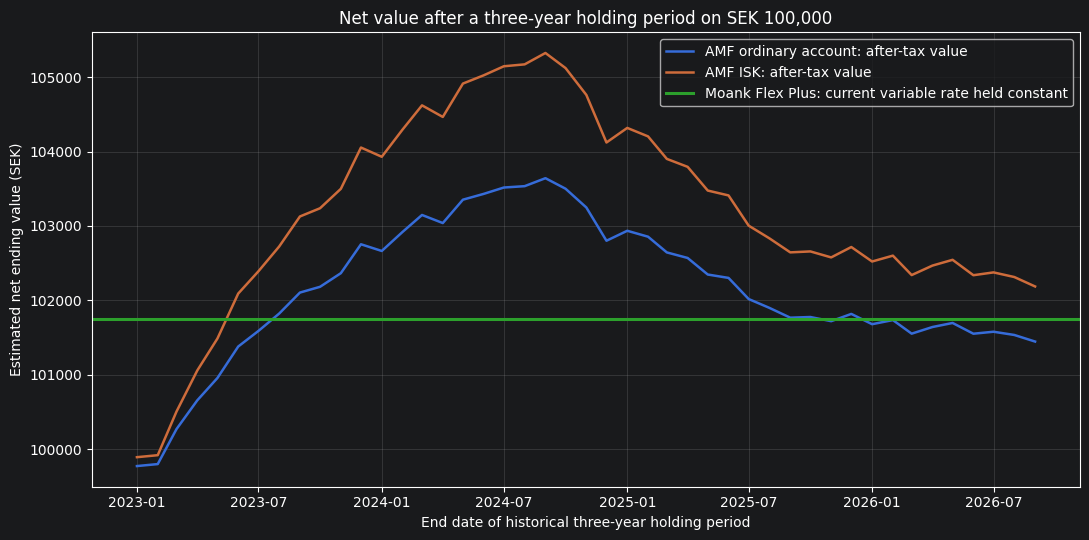

,AMF ordinary net value (SEK),AMF ISK net value (SEK)
5th percentile,"99,997","100,117"
25th percentile,"101,623","102,440"
Median,"102,004","102,984"
75th percentile,"102,895","104,261"
95th percentile,"103,550","105,193"


Historical windows run from 2022-01-03 to 2026-09-23.


In [49]:
rolling_monthly = (rolling.assign(period_end_month=rolling.end_date.dt.to_period("M"))
                   .groupby("period_end_month", as_index=False).last())
rolling_monthly["period_end_month"] = rolling_monthly.period_end_month.dt.to_timestamp()

# Recreate the savings scenario if this chart cell is rerun without rerunning the model cell.
if "moank_net_maturity_value" in globals():
    savings_scenario_value = moank_net_maturity_value
else:
    savings_scenario_value = INVESTMENT_SEK
    for _year in range(COMPARISON_TERM_MONTHS // 12):
        savings_scenario_value += savings_scenario_value * MOANK_FLEX_PLUS_GROSS_RATE * (1 - CAPITAL_GAINS_TAX_RATE)

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(rolling_monthly.period_end_month, rolling_monthly.ordinary_net_sek,
        label="AMF ordinary account: after-tax value", linewidth=1.8)
ax.plot(rolling_monthly.period_end_month, rolling_monthly.isk_net_sek,
        label="AMF ISK: after-tax value", linewidth=1.8)
ax.axhline(savings_scenario_value, color="#2ca02c", linewidth=2.2,
           label="Moank Flex Plus: current variable rate held constant")
ax.set(title=f"Net value after a {COMPARISON_TERM_YEARS}-year holding period on SEK {INVESTMENT_SEK:,.0f}",
       xlabel="End date of historical holding period", ylabel="Estimated net ending value (SEK)")
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

range_table = rolling[["ordinary_net_sek", "isk_net_sek"]].quantile([0.05, 0.25, 0.50, 0.75, 0.95]).rename(index={
    0.05: "5th percentile", 0.25: "25th percentile", 0.50: "Median", 0.75: "75th percentile", 0.95: "95th percentile"
}).rename(columns={"ordinary_net_sek": "AMF ordinary net value (SEK)", "isk_net_sek": "AMF ISK net value (SEK)"})
display(range_table.style.format("{:,.0f}"))
print(f"Historical windows run from {rolling.start_date.min().date()} to {rolling.end_date.max().date()}.")


## Cost and limitation summary

| Item | Moank Flex Plus | AMF on Avanza ordinary account | AMF on Avanza ISK |
|---|---|---|---|
| Account/platform fee | None modeled | Avanza fund trades assumed commission-free | Avanza fund trades assumed commission-free |
| Fund fee | Not applicable | 0.10%/year, embedded in NAV | 0.10%/year, embedded in NAV |
| Tax | 30% withholding on interest, assumed yearly | 0.12% annual fund-share tax plus 30% tax on positive realized gain | Annual ISK tax; toggle the 2026 exemption in the inputs |
| Capital protection | Deposit terms and Swedish deposit guarantee up to SEK 1,150,000 per person; check all balances at Moank | No capital guarantee; fund NAV can fall | No capital guarantee; fund NAV can fall |
| Liquidity | Variable-rate account; withdrawals allowed | Fund sale subject to dealing/settlement | Fund sale subject to dealing/settlement |

Moank's current rate can change at any time, so the three-year value is a constant-rate scenario rather than a promised return. Moank says Flex Plus interest accrues daily and is capitalized annually or when the account closes; this model applies annual tax withholding before compounding. AMF Räntefond Kort holds bonds and can still lose value, though it has shorter interest-rate exposure than a long-duration bond fund. The ISK estimate applies the entered remaining exemption only when `APPLY_ISK_TAX_FREE_ALLOWANCE = True`; when False, it taxes the full modeled capital base.


## Dynamic conclusion

This section ranks the three choices by modeled net ending value using today's Moank rate held constant for the scenario and the median historical three-year outcomes for AMF. It also reports which AMF account type did better in the latest trailing three-year window. The ranking updates when the notebook is rerun after changing the tax switch, tax allowance, rate, investment amount, or NAV data.


In [50]:
median_values = pd.Series({
    "Moank Flex Plus (current variable rate held constant)": moank_net_maturity_value,
    "AMF Räntefond Kort on Avanza (ordinary account, historical median)": rolling.ordinary_net_sek.median(),
    "AMF Räntefond Kort on Avanza ISK (historical median)": rolling.isk_net_sek.median(),
}, name="Net ending value (SEK)").sort_values(ascending=False)

latest_values = pd.Series({
    "AMF ordinary account": latest_window.ordinary_net_sek,
    "AMF ISK": latest_window.isk_net_sek,
}, name="Net ending value (SEK)").sort_values(ascending=False)

print("Median historical comparison plus current Moank Flex Plus rate:")
display(median_values.to_frame().style.format("SEK {:,.0f}"))
best_option = median_values.index[0]
second_option = median_values.index[1]
advantage = median_values.iloc[0] - median_values.iloc[1]
latest_best = latest_values.index[0]
allowance_status = (
    f"The ISK tax-free allowance is included (SEK {ISK_ALLOWANCE_AVAILABLE_SEK:,.0f} available)."
    if APPLY_ISK_TAX_FREE_ALLOWANCE
    else "The ISK tax-free allowance is switched off; the full modeled ISK capital base is taxed."
)

from IPython.display import Markdown
display(Markdown(
    f"**Highest modeled net ending value:** {best_option}, at SEK {median_values.iloc[0]:,.0f} "
    f"for a SEK {INVESTMENT_SEK:,.0f} starting investment. It is SEK {advantage:,.0f} above "
    f"{second_option}, the next-highest option under these inputs.\n\n"
    f"**Latest trailing fund window ({latest_window.start_date.date()} to {latest_window.end_date.date()}):** "
    f"{latest_best} had the higher estimated after-tax value (SEK {latest_values.iloc[0]:,.0f}). "
    f"{allowance_status} "
    "This is a ranking by modeled after-tax value, not a forecast or a universal recommendation. "
    "The fund figures are historical and can include losses. Moank Flex Plus uses today's variable rate held constant for the scenario; that rate is not locked. Verify the applicable deposit guarantee and your total balance against its cap."
))


Median historical comparison plus current Moank Flex Plus rate:


,Net ending value (SEK)
AMF Räntefond Kort on Avanza ISK (historical median),"SEK 102,984"
"AMF Räntefond Kort on Avanza (ordinary account, historical median)","SEK 102,004"
Moank Flex Plus (current variable rate held constant),"SEK 101,750"


**Highest modeled net ending value:** AMF Räntefond Kort on Avanza ISK (historical median), at SEK 102,984 for a SEK 100,000 starting investment. It is SEK 980 above AMF Räntefond Kort on Avanza (ordinary account, historical median), the next-highest option under these inputs.

**Latest trailing fund window (2025-09-23 to 2026-09-23):** AMF ISK had the higher estimated after-tax value (SEK 102,187). The ISK tax-free allowance is included (SEK 300,000 available). This is a ranking by modeled after-tax value, not a forecast or a universal recommendation. The fund figures are historical and can include losses. Moank Flex Plus uses today's variable rate held constant for the scenario; that rate is not locked. Verify the applicable deposit guarantee and your total balance against its cap.